In [1]:
# Import packages
from pathlib import Path

project_dir = Path("/home/mcaskey/10XvParse/")
analysis_name = "Analysis_3"
analysis_dir = Path.cwd() 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
import anndata as ad
import scanpy as sc

from XvP_utils import processing

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
# # In case you change the package
# import importlib
# importlib.reload(processing)

In [5]:
def get_kb_dir(project_dir: Path, assay: str, type: str = None) -> Path:
    if type is None:
        kb_dir = project_dir / "Data" / analysis_name / assay / "kb_python" / "sampled_out"
    else:
        kb_dir = project_dir / "Data" / analysis_name / assay / "kb_python" / f"sampled_{type}_out"
    return kb_dir

In [ ]:
sample = 'H2'

data_10x = processing.initProcessing(data_name=f"10x_{sample}", kb_dir=get_kb_dir(project_dir=project_dir, assay=f"10x_{sample}"), data_title=f"{sample} 10X Genomics")
data_polyT = processing.initProcessing(data_name=f"polyT_{sample}", kb_dir=get_kb_dir(project_dir=project_dir, assay=f"parse_{sample}", type="polyT"), data_title=f"{sample} Parse 3'")
data_randO = processing.initProcessing(data_name=f"randO_{sample}", kb_dir=get_kb_dir(project_dir=project_dir, assay=f"parse_{sample}", type="randO"), data_title=f"{sample} Parse Random Oligo")
data_parse = processing.initProcessing(data_name=f"parse_{sample}", kb_dir=get_kb_dir(project_dir=project_dir, assay=f"parse_{sample}"), data_title=f"{sample} Parse", modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]


# Population Upsampling Estimation

In [ ]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True, sharex=True)

for i, data in enumerate(raw_datasets):
    processing.scatter_reads(ax[i], data)

ax[0].set_ylabel("Genes Detected")

plt.tight_layout()
plt.show()


In [ ]:
# Path to save gene metadata so don't need to query Ensembl 
# more than once
gene_info = processing.queryEnsembl(analysis_dir, species="hsapiens") 

In [ ]:
for data in raw_datasets:
    data = processing.add_cell_metrics(data, gene_info)


In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True, sharex=True)
for i, data in enumerate(raw_datasets):
    processing.mito_scatter(ax[i], data)

ax[0].set_ylabel("Percent Mitochondrial Counts")

plt.tight_layout()
plt.show()


In [ ]:
fig, axs = plt.subplots(1,4,figsize=(20, 5))

for ax, data in zip(axs, raw_datasets):
    x = np.asarray(data.X.sum(axis=1))[:,0]
    y = np.asarray(np.sum(data.X>0, axis=1))[:,0]

    ribo_content = np.log(data.obs['percent_ribo']).tolist()

    im = ax.scatter(x, y, c=ribo_content, cmap = 'viridis', alpha=0.05)
    ax.set_xlabel("UMI Counts")
    ax.set_ylabel("Genes Detected")
    ax.set_xscale('log')
    ax.set_yscale('log', nonpositive='clip')
    ax.set_title(data.uns['title']+" Reads")

fig.colorbar(im, ax=ax)

plt.show()


In [13]:
def get_mean_distance(data, ribo_thresh = None, distance = cosine_distances):
    if ribo_thresh:
        data = data[data.obs['percent_ribo'] < ribo_thresh]
    mean_cell = np.asarray(data.X.mean(axis=0))
    dist = distance(data.X, mean_cell)
    return data, dist

In [ ]:
fig, axs = plt.subplots(1,4,figsize=(20, 5))

for ax, data in zip(axs, raw_datasets):
    filtered_data, dist = get_mean_distance(data)
    x = np.asarray(filtered_data.X.sum(axis=1))[:,0]
    y = np.asarray(np.sum(filtered_data.X>0, axis=1))[:,0]

    im = ax.scatter(x, y, c=dist, cmap = 'viridis', alpha=0.25)
    ax.set_xlabel("UMI Counts")
    ax.set_ylabel("Genes Detected")
    ax.set_xscale('log')
    ax.set_yscale('log', nonpositive='clip')
    ax.set_title(data.uns['title']+" Reads")

fig.colorbar(im, ax=ax)

plt.show()


In [ ]:
fig, axs = plt.subplots(1,4,figsize=(20, 5))

for ax, data in zip(axs, raw_datasets):
    filtered_data, dist = get_mean_distance(data, distance = euclidean_distances)
    dist = np.log(dist) / np.max(np.log(dist))
    x = np.asarray(filtered_data.X.sum(axis=1))[:,0]
    y = np.asarray(np.sum(filtered_data.X>0, axis=1))[:,0]

    im = ax.scatter(x, y, c=dist, cmap = 'viridis', alpha=0.25)
    ax.set_xlabel("UMI Counts")
    ax.set_ylabel("Genes Detected")
    ax.set_xscale('log')
    ax.set_yscale('log', nonpositive='clip')
    ax.set_title(data.uns['title']+" Reads")

fig.colorbar(im, ax=ax)

plt.show()


In [ ]:
cutoffs = [150, 600, 600, 600]
fig, ax = plt.subplots(1, 4, figsize=(27,5), sharey=True, sharex=True)

datasets = []
for i, (data, cutoff) in enumerate(zip(raw_datasets, cutoffs)):
    datasets.append(processing.knee_plot(ax[i], data, cutoff=cutoff))

ax[0].set_ylabel("Set of Barcodes")

plt.tight_layout()
plt.show()


In [ ]:
full_gene_info_path = project_dir / analysis_dir
gene_info = processing.updateGeneInfo(gene_info, datasets, full_gene_info_path)


In [ ]:
processing.plot_filtering_metrics(datasets)


In [ ]:
groups = ['n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

processing.plot_cell_metrics(datasets, groups=groups, group_names=group_names, figsize=(12,18))


In [ ]:
processing.plot_gene_metrics(datasets, sample_size = 1000000)


# Doublet Detection Comparison

In [ ]:
scrubs = processing.detect_doublets(datasets)


In [ ]:
bottom = np.zeros(len(datasets))
titles = [data.uns['title'] for data in datasets]
percent_doublets = [data.obs['predicted_doublet'].sum()/len(data.obs)*100 for data in datasets]

plt.bar(titles, percent_doublets)
plt.ylabel('Percentage of Predicted Doublets')
plt.title('Predicted Doublet Percentage by Method')

plt.show()


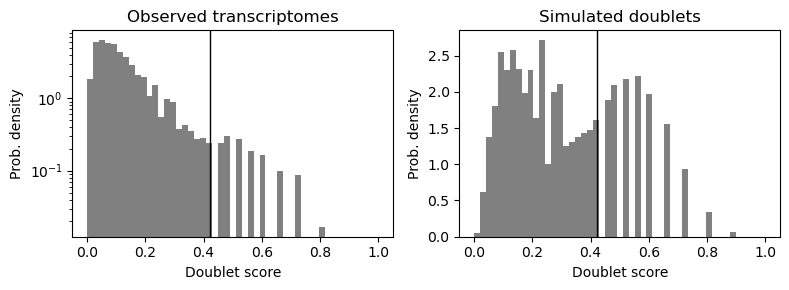

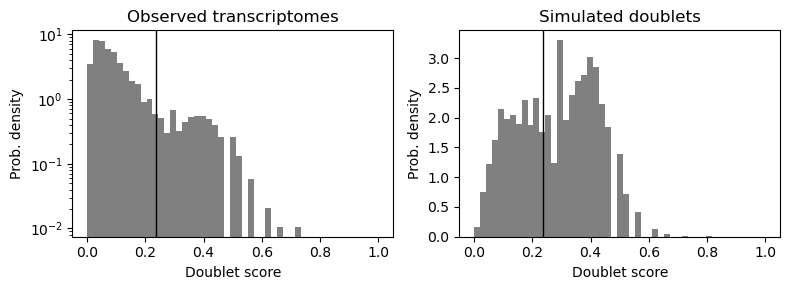

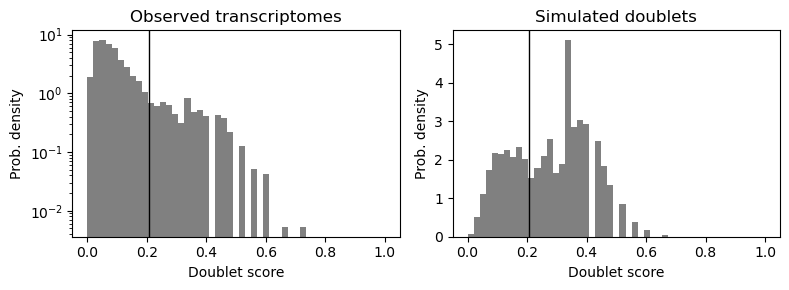

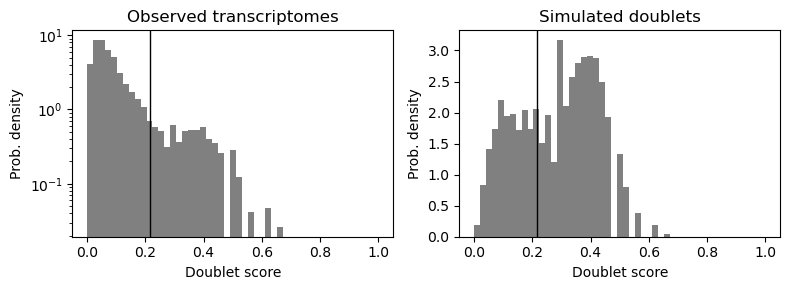

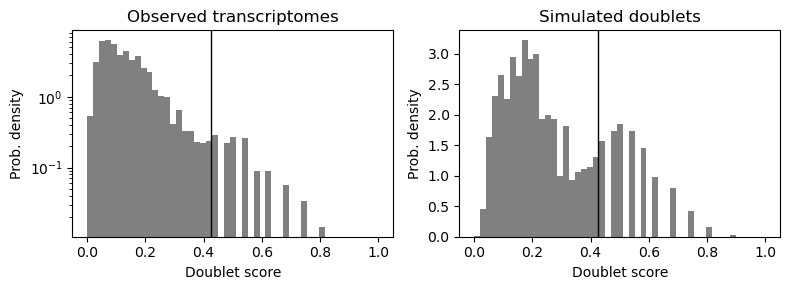

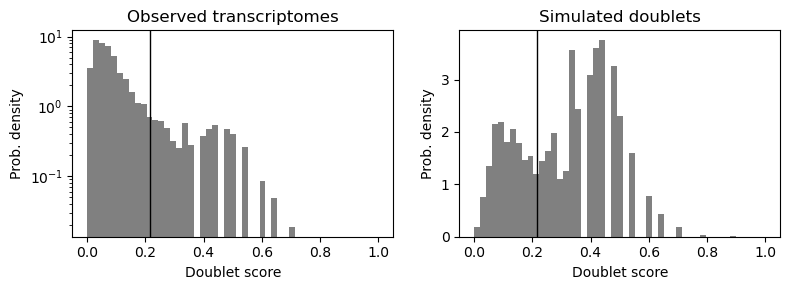

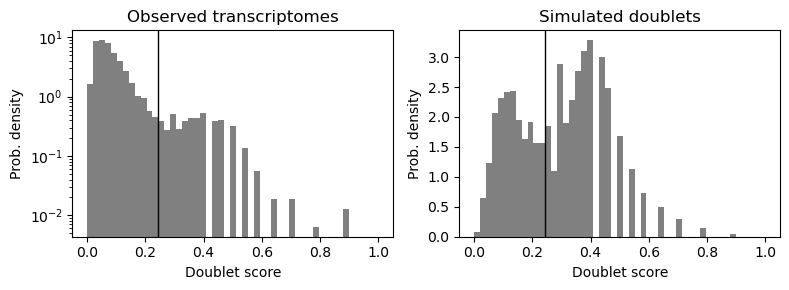

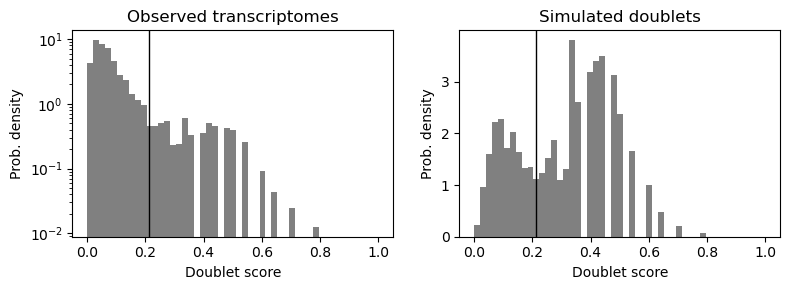

In [23]:
# Should see two peaks separated by threshold
for scrub in scrubs:
    scrub.plot_histogram()

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use

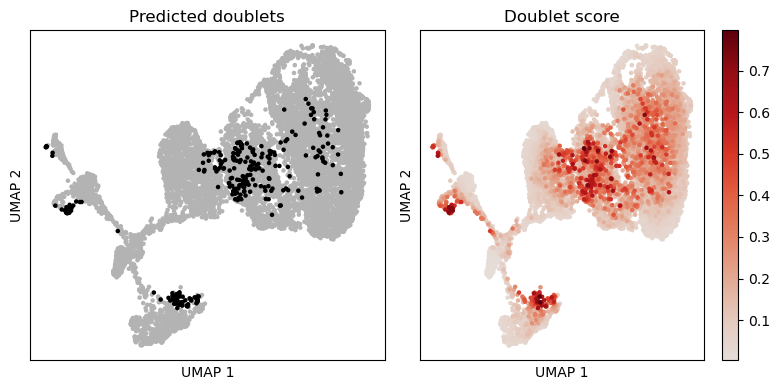

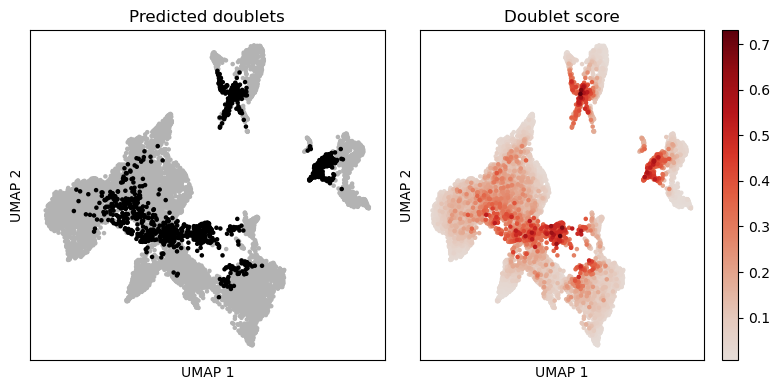

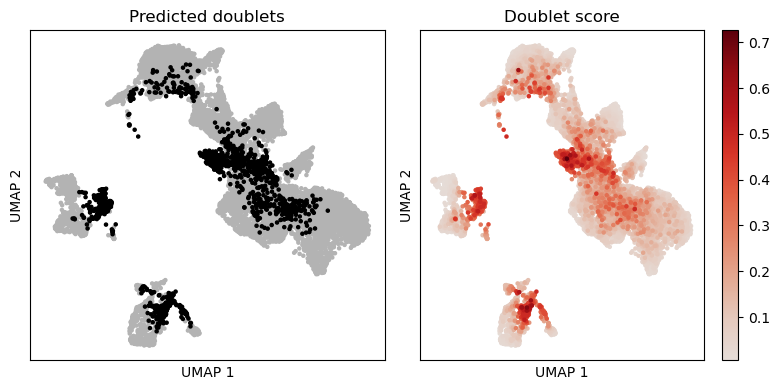

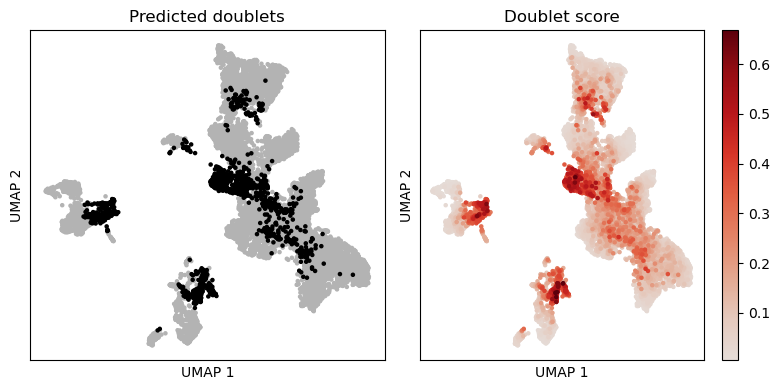

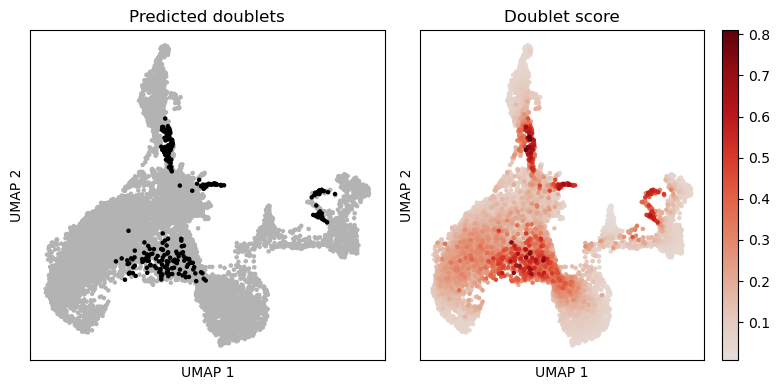

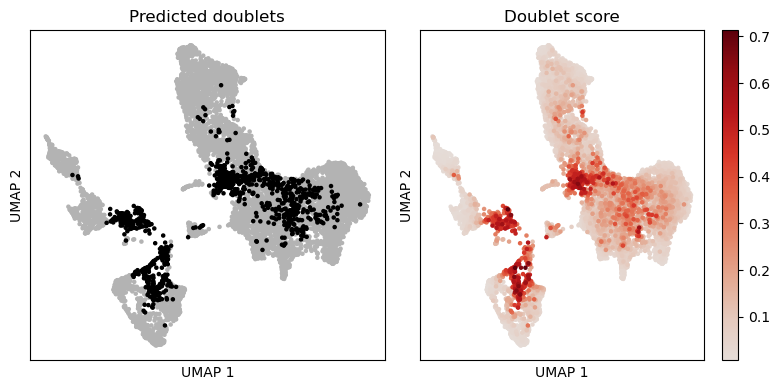

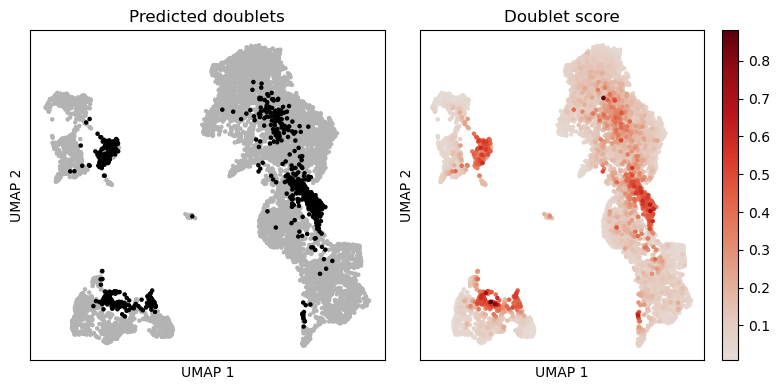

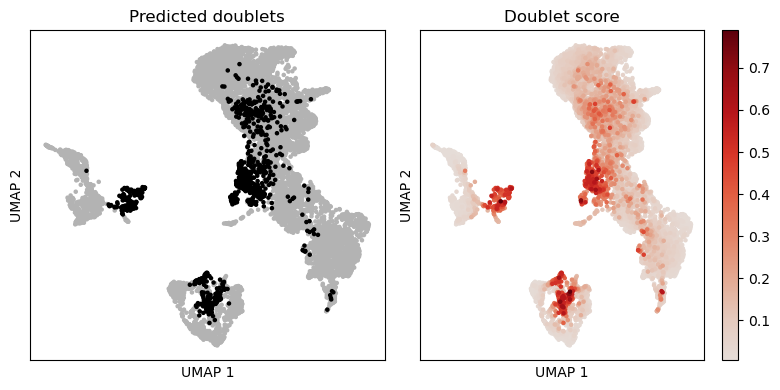

In [24]:
# Should see clustering of doublets
for scrub in scrubs:
    scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3)) 
    scrub.plot_embedding('UMAP', order_points=True)

# Read/Gene Comparisons

In [25]:
# Marker genes for PBMCs from www.biocompare.com
T_marker_names = ['CD3D', 'CD3G','CD3E', 'CD4', 'CD8A', 'CD8B']
T_markers = ['ENSG00000167286.12', 'ENSG00000160654.11', 
             'ENSG00000198851.10', 'ENSG00000010610.10', 
             'ENSG00000153563.17', 'ENSG00000172116.23']

B_marker_names = ['CD19', 'CD24', 'CD40', 'CD72']
B_markers = ['ENSG00000177455.15', 'ENSG00000272398.6'
             'ENSG00000101017.15', 'ENSG00000137101.14']

NK_marker_names = ['FCGR3A', 'FCGR3B', 'NCAM1']
NK_markers = ['ENSG00000203747.13', 'ENSG00000162747.13', 'ENSG00000149294.18']

monocyte_marker_names = ['CD14'] # and CD16
monocyte_markers = ['ENSG00000170458.15']

markers = T_markers + B_markers + NK_markers + monocyte_markers
marker_names = T_marker_names + B_marker_names + NK_marker_names + monocyte_marker_names

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    processing.marker_genes(ax[i], data, T_marker_names)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    processing.top_gene_counts(ax[i], data)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)
for i, data in enumerate(datasets):
    processing.top_gene_cell_expression(ax[i], data)

ax[0].set_ylabel("% counts per cell")

plt.tight_layout()
plt.show()


In [ ]:
compare_names, compare_dfs = processing.compare(datasets, 8)


In [ ]:
_, _ = processing.compare(datasets, 1.5)


In [ ]:
_, _ = processing.compare(datasets, 0.5)


In [ ]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = processing.mergeByCooks(gene_info, name, df)

full_gene_info_path = 'gene_comparisons.csv'
gene_info.to_csv(full_gene_info_path)


In [ ]:
cell_thresh = 10
contents = processing.generate_upset(datasets, gene_info, cell_thresh)


In [ ]:
# Extract gene subsets that were interesting in the upset plot

set_names = ['10X', 'Parse and Parse Random Oligo', '10X, Parse, and Parse Random Oligo', 'All Methods']
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

tech_vals = ['10x', 'polyT', 'randO', 'parse']
tech_keys = [data.uns['name'] for data in datasets]
techs = dict(zip(tech_vals, tech_keys))

genes_10x = contents['gene_ids'][contents[techs['10x']]& 
                                ~contents[techs['polyT']]&
                                ~contents[techs['randO']]&
                                ~contents[techs['parse']]]
genes_10x = genes_10x.tolist()

genes_PO = contents['gene_ids'][~contents[techs['10x']]& 
                            ~contents[techs['polyT']]&
                            contents[techs['randO']]&
                            contents[techs['parse']]]
genes_PO = genes_PO.tolist()

genes_XPO = contents['gene_ids'][contents[techs['10x']]& 
                            ~contents[techs['polyT']]&
                            contents[techs['randO']]&
                            contents[techs['parse']]]
genes_XPO = genes_XPO.tolist()

genes_all = contents['gene_ids'][contents[techs['10x']]& 
                            contents[techs['polyT']]&
                            contents[techs['randO']]&
                            contents[techs['parse']]]
genes_all = genes_all.tolist()

gene_sets = [genes_10x, genes_PO, genes_XPO, genes_all]
processing.plot_geneset_metrics(gene_sets, set_names, gene_info)
processing.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)


In [ ]:
# Look at top 1000 genes for each method instead of all
cell_thresh = 10

contents = processing.generate_upset(datasets, gene_info, cell_thresh, n_top_genes=1000)


In [ ]:
geneset_names = ['10X', 'Parse Methods', 'All Methods']
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

tech_vals = ['10x', 'polyT', 'randO', 'parse']
tech_keys = [data.uns['name'] for data in datasets]
techs = dict(zip(tech_vals, tech_keys))

genes_10x = contents['gene_ids'][contents[techs['10x']]& 
                                ~contents[techs['polyT']]&
                                ~contents[techs['randO']]&
                                ~contents[techs['parse']]]
genes_10x = genes_10x.tolist()

genes_POT = contents['gene_ids'][~contents[techs['10x']]& 
                                contents[techs['polyT']]&
                                contents[techs['randO']]&
                                contents[techs['parse']]]
genes_POT = genes_POT.tolist()

genes_all = contents['gene_ids'][contents[techs['10x']]& 
                                contents[techs['polyT']]&
                                contents[techs['randO']]&
                                contents[techs['parse']]]
genes_all = genes_all.tolist()

genesets = [genes_10x, genes_POT, genes_all]
processing.plot_geneset_metrics(gene_sets, set_names, gene_info)
processing.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)
